In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
df = pd.read_csv('MUP_DPR_RY26_P04_V10_DY24_NPIBN.csv', nrows=500000)
print(f"Sample loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")

Sample loaded: 500,000 rows, 22 columns

Columns: ['Prscrbr_NPI', 'Prscrbr_Last_Org_Name', 'Prscrbr_First_Name', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_State_FIPS', 'Prscrbr_Type', 'Prscrbr_Type_Src', 'Brnd_Name', 'Gnrc_Name', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Day_Suply', 'Tot_Drug_Cst', 'Tot_Benes', 'GE65_Sprsn_Flag', 'GE65_Tot_Clms', 'GE65_Tot_30day_Fills', 'GE65_Tot_Drug_Cst', 'GE65_Tot_Day_Suply', 'GE65_Bene_Sprsn_Flag', 'GE65_Tot_Benes']


/var/folders/wx/slj5n9mx5_x5hpgtg68lnd_w0000gn/T/ipykernel_28352/916191343.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('MUP_DPR_RY26_P04_V10_DY24_NPIBN.csv', nrows=500000)


In [3]:
# Section 1: Top 10 prescribers by total drug cost — anonymized
top10 = (df.groupby('Prscrbr_NPI')['Tot_Drug_Cst']
           .sum()
           .reset_index()
           .sort_values('Tot_Drug_Cst', ascending=False)
           .head(10))

top10 = top10.reset_index(drop=True)
top10['Prescriber_ID'] = ['Prescriber-' + str(i+1).zfill(3) for i in range(len(top10))]
top10 = top10[['Prescriber_ID', 'Tot_Drug_Cst']].copy()
top10['Tot_Drug_Cst'] = top10['Tot_Drug_Cst'].round(2)

print("TOP 10 PRESCRIBERS BY TOTAL DRUG COST:")
display(top10)

TOP 10 PRESCRIBERS BY TOTAL DRUG COST:


,Prescriber_ID,Tot_Drug_Cst
0,Prescriber-001,41690176.03
1,Prescriber-002,17660241.43
2,Prescriber-003,14841387.65
3,Prescriber-004,13902581.59
4,Prescriber-005,13642124.74
5,Prescriber-006,12970420.06
6,Prescriber-007,12815139.91
7,Prescriber-008,11707871.27
8,Prescriber-009,9719040.72
9,Prescriber-010,9102070.46


In [4]:
# Section 2: Anomaly detection
spending_by_npi = df.groupby('Prscrbr_NPI')['Tot_Drug_Cst'].sum()

average   = spending_by_npi.mean()
std       = spending_by_npi.std()
threshold = average + 2 * std

print(f"Average spending per prescriber:  ${average:,.2f}")
print(f"Standard deviation:               ${std:,.2f}")
print(f"Anomaly threshold (mean+2σ):      ${threshold:,.2f}")

anomalies = spending_by_npi[spending_by_npi > threshold].reset_index()
anomalies = anomalies.sort_values('Tot_Drug_Cst', ascending=False).reset_index(drop=True)
anomalies['Prescriber_ID'] = ['Prescriber-' + str(i+1).zfill(3) for i in range(len(anomalies))]
anomalies = anomalies[['Prescriber_ID', 'Tot_Drug_Cst']]

print(f"\nAnomalous prescribers:  {len(anomalies):,}")
print(f"Share of total:         {len(anomalies)/len(spending_by_npi)*100:.1f}%")
display(anomalies.head(10))

Average spending per prescriber:  $196,534.89
Standard deviation:               $673,674.39
Anomaly threshold (mean+2σ):      $1,543,883.66

Anomalous prescribers:  510
Share of total:         2.4%


,Prescriber_ID,Tot_Drug_Cst
0,Prescriber-001,41690176.03
1,Prescriber-002,17660241.43
2,Prescriber-003,14841387.65
3,Prescriber-004,13902581.59
4,Prescriber-005,13642124.74
5,Prescriber-006,12970420.06
6,Prescriber-007,12815139.91
7,Prescriber-008,11707871.27
8,Prescriber-009,9719040.72
9,Prescriber-010,9102070.46


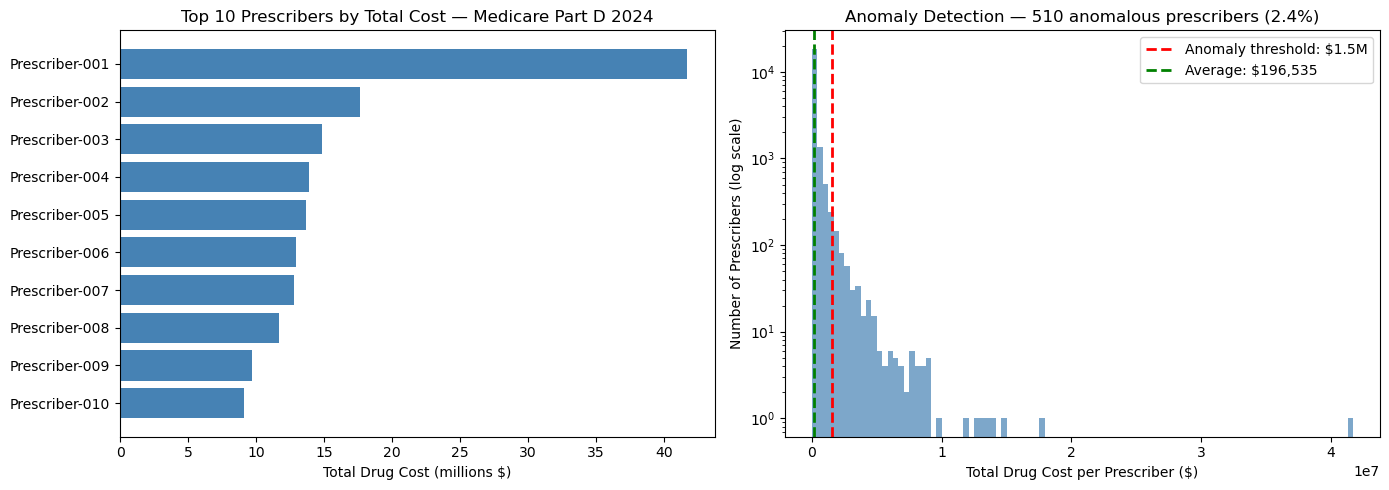

Chart saved ✅


In [5]:
# Section 3: Visualizations — anonymized
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(
    top10['Prescriber_ID'],
    top10['Tot_Drug_Cst'] / 1_000_000,
    color='steelblue'
)
axes[0].set_xlabel('Total Drug Cost (millions $)')
axes[0].set_title('Top 10 Prescribers by Total Cost — Medicare Part D 2024')
axes[0].invert_yaxis()

axes[1].hist(spending_by_npi, bins=100, color='steelblue', alpha=0.7, log=True)
axes[1].axvline(threshold, color='red', linestyle='--', linewidth=2,
                label=f'Anomaly threshold: ${threshold/1e6:.1f}M')
axes[1].axvline(average, color='green', linestyle='--', linewidth=2,
                label=f'Average: ${average:,.0f}')
axes[1].set_xlabel('Total Drug Cost per Prescriber ($)')
axes[1].set_ylabel('Number of Prescribers (log scale)')
axes[1].set_title(f'Anomaly Detection — {len(anomalies):,} anomalous prescribers (2.4%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('cms_anomaly_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

In [6]:
print("=" * 58)
print("SUMMARY — CMS Medicare Part D Anomaly Analysis")
print("=" * 58)
print(f"Dataset:                  CMS Medicare Part D 2024")
print(f"Sample analyzed:          500,000 records")
print(f"Unique prescribers:       {len(spending_by_npi):,}")
print(f"Average spending:         ${average:,.2f}")
print(f"Anomaly threshold:        ${threshold:,.2f}")
print(f"Anomalous prescribers:    {len(anomalies):,} ({len(anomalies)/len(spending_by_npi)*100:.1f}%)")
print(f"Top outlier:              Prescriber-001 — ${anomalies.iloc[0]['Tot_Drug_Cst']:,.0f}")
print("=" * 58)
print("Analysis complete ✅")

SUMMARY — CMS Medicare Part D Anomaly Analysis
Dataset:                  CMS Medicare Part D 2024
Sample analyzed:          500,000 records
Unique prescribers:       21,025
Average spending:         $196,534.89
Anomaly threshold:        $1,543,883.66
Anomalous prescribers:    510 (2.4%)
Top outlier:              Prescriber-001 — $41,690,176
Analysis complete ✅


In [3]:
# Section 4: Geographic Analysis — Anomalous prescribers by state (per capita)
# State population data (2024 census estimates)

state_population = {
    'AL': 5108468, 'AK': 733583, 'AZ': 7431344, 'AR': 3067732,
    'CA': 39538223, 'CO': 5877610, 'CT': 3605944, 'DE': 1003384,
    'FL': 22610726, 'GA': 10912876, 'HI': 1440196, 'ID': 1939033,
    'IL': 12582032, 'IN': 6785528, 'IA': 3190369, 'KS': 2937880,
    'KY': 4509394, 'LA': 4590241, 'ME': 1395722, 'MD': 6177224,
    'MA': 7029917, 'MI': 10077331, 'MN': 5706494, 'MS': 2961279,
    'MO': 6154913, 'MT': 1122867, 'NE': 1961504, 'NV': 3104614,
    'NH': 1377529, 'NJ': 9288994, 'NM': 2117522, 'NY': 20201249,
    'NC': 10439388, 'ND': 779094, 'OH': 11799448, 'OK': 3959353,
    'OR': 4237256, 'PA': 13002700, 'RI': 1097379, 'SC': 5118425,
    'SD': 886667, 'TN': 6910840, 'TX': 29145505, 'UT': 3271616,
    'VT': 643077, 'VA': 8631393, 'WA': 7705281, 'WV': 1793716,
    'WI': 5893718, 'WY': 576851, 'DC': 689545
}

# Get prescriber state from original data
df_state = df[['Prscrbr_NPI', 'Prscrbr_State_Abrvtn', 'Tot_Drug_Cst']].copy()

# Total spending by prescriber
spending_by_npi = df_state.groupby(['Prscrbr_NPI', 'Prscrbr_State_Abrvtn'])['Tot_Drug_Cst'].sum().reset_index()

# Identify anomalous prescribers
avg = spending_by_npi['Tot_Drug_Cst'].mean()
std = spending_by_npi['Tot_Drug_Cst'].std()
threshold = avg + 2 * std

anomalies_geo = spending_by_npi[spending_by_npi['Tot_Drug_Cst'] > threshold].copy()

# Count anomalous prescribers by state
state_anomalies = anomalies_geo.groupby('Prscrbr_State_Abrvtn').size().reset_index()
state_anomalies.columns = ['State', 'Anomalous_Prescribers']

# Total prescribers by state
state_total = spending_by_npi.groupby('Prscrbr_State_Abrvtn').size().reset_index()
state_total.columns = ['State', 'Total_Prescribers']

# Merge
state_summary = state_total.merge(state_anomalies, on='State', how='left')
state_summary['Anomalous_Prescribers'] = state_summary['Anomalous_Prescribers'].fillna(0).astype(int)

# Add population and calculate per-capita rate
state_summary['Population'] = state_summary['State'].map(state_population)
state_summary = state_summary.dropna(subset=['Population'])
state_summary['Anomalous_Rate_pct'] = (state_summary['Anomalous_Prescribers'] / state_summary['Total_Prescribers'] * 100).round(2)
state_summary['Anomalous_Per_100k'] = (state_summary['Anomalous_Prescribers'] / state_summary['Population'] * 100000).round(2)

# Sort by anomalous rate
state_summary = state_summary.sort_values('Anomalous_Rate_pct', ascending=False)

print("TOP 15 STATES BY ANOMALOUS PRESCRIBER RATE:")
print(state_summary[['State', 'Total_Prescribers', 'Anomalous_Prescribers', 'Anomalous_Rate_pct', 'Anomalous_Per_100k']].head(15).to_string(index=False))

TOP 15 STATES BY ANOMALOUS PRESCRIBER RATE:
State  Total_Prescribers  Anomalous_Prescribers  Anomalous_Rate_pct  Anomalous_Per_100k
   AL                297                     15                5.05                0.29
   KS                177                      8                4.52                0.27
   KY                340                     14                4.12                0.31
   SC                352                     14                3.98                0.27
   TN                461                     16                3.47                0.23
   MS                177                      6                3.39                0.20
   MI                768                     24                3.12                0.24
   CT                291                      9                3.09                0.25
   NY               1508                     45                2.98                0.22
   OK                240                      7                2.92         

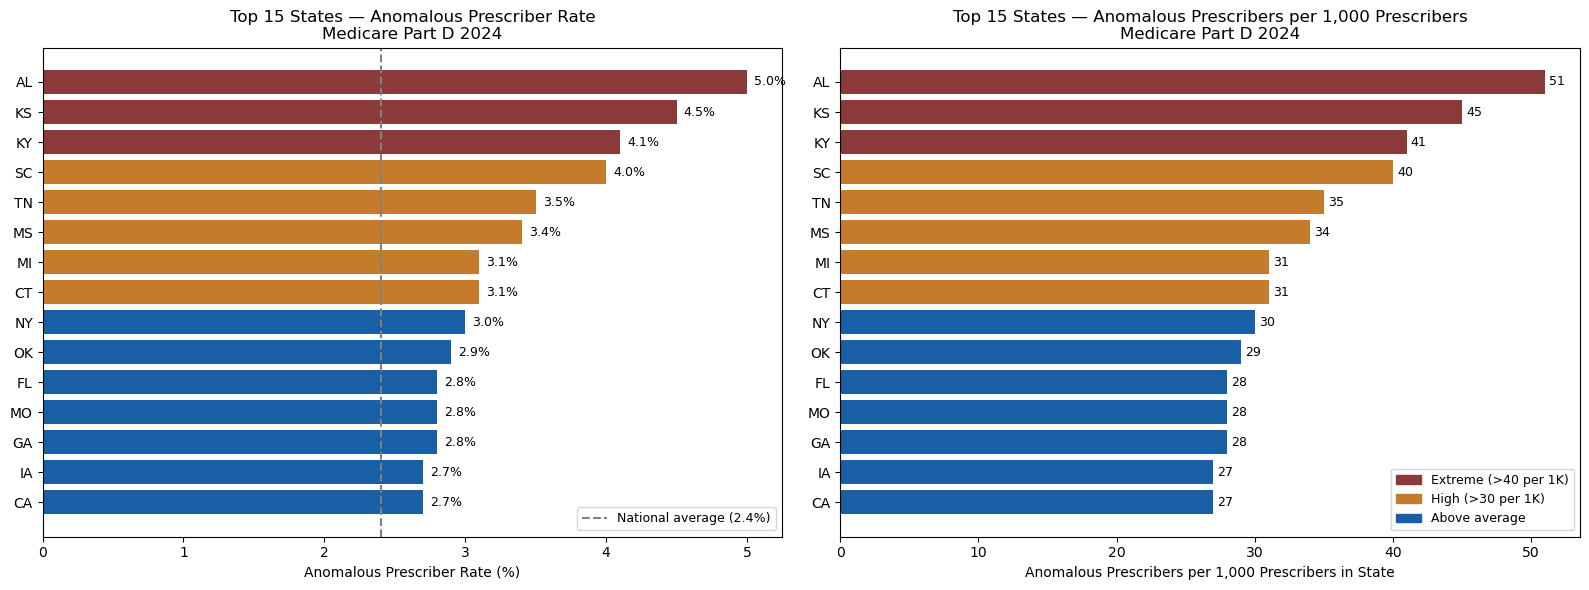

Geographic analysis chart saved ✅


In [7]:
# Section 4: Visualization — Geographic anomaly rate
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Calculate anomalous prescribers per 1,000 total prescribers in state
state_summary['Anomalous_Per_1k_Prescribers'] = (
    state_summary['Anomalous_Prescribers'] / 
    state_summary['Total_Prescribers'] * 1000
).round(0).astype(int)

# Round anomalous rate to 1 decimal for cleaner display
state_summary['Anomalous_Rate_pct'] = state_summary['Anomalous_Rate_pct'].round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — Top 15 states by anomalous prescriber rate (%)
top15 = state_summary.nlargest(15, 'Anomalous_Rate_pct')
colors = ['#8B3A3A' if r > 4 else '#C47B2B' if r > 3 else '#185FA5'
          for r in top15['Anomalous_Rate_pct']]

axes[0].barh(top15['State'], top15['Anomalous_Rate_pct'], color=colors)
axes[0].set_xlabel('Anomalous Prescriber Rate (%)')
axes[0].set_title('Top 15 States — Anomalous Prescriber Rate\nMedicare Part D 2024')
axes[0].invert_yaxis()
axes[0].axvline(x=2.4, color='gray', linestyle='--', linewidth=1.5,
                label='National average (2.4%)')
axes[0].legend(fontsize=9)

for i, (val, state) in enumerate(zip(top15['Anomalous_Rate_pct'], top15['State'])):
    axes[0].text(val + 0.05, i, f'{val}%', va='center', fontsize=9)

# Chart 2 — Anomalous prescribers per 1,000 prescribers in state
top15_per1k = state_summary.nlargest(15, 'Anomalous_Per_1k_Prescribers')
colors2 = ['#8B3A3A' if r > 40 else '#C47B2B' if r > 30 else '#185FA5'
           for r in top15_per1k['Anomalous_Per_1k_Prescribers']]

axes[1].barh(top15_per1k['State'], top15_per1k['Anomalous_Per_1k_Prescribers'], color=colors2)
axes[1].set_xlabel('Anomalous Prescribers per 1,000 Prescribers in State')
axes[1].set_title('Top 15 States — Anomalous Prescribers per 1,000 Prescribers\nMedicare Part D 2024')
axes[1].invert_yaxis()

for i, (val, state) in enumerate(zip(top15_per1k['Anomalous_Per_1k_Prescribers'], top15_per1k['State'])):
    axes[1].text(val + 0.3, i, f'{val:,}', va='center', fontsize=9)

# Legend
red_patch = mpatches.Patch(color='#8B3A3A', label='Extreme (>40 per 1K)')
amber_patch = mpatches.Patch(color='#C47B2B', label='High (>30 per 1K)')
blue_patch = mpatches.Patch(color='#185FA5', label='Above average')
axes[1].legend(handles=[red_patch, amber_patch, blue_patch], fontsize=9)

plt.tight_layout()
plt.savefig('cms_geographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Geographic analysis chart saved ✅")